# Values to compare
#### Target: overall_survival_months

#### Predictors:
#### age_at_diagnosis, cancer_type_detailed, chemotherapy, tumor_stage, tumor_size, type_of_breast_surgery death_from_cancer, 

#### Definitions
#### Invasive Ductal Carcinoma (IDC): IDC (approx. 80% of cases) starts in milk ducts and forms lumps
#### Invasive Lobular Carcinoma (ILC): ILC (10-15% of cases) starts in milk-producing lobules, often growing in single-file lines that make it harder to detect on mammograms. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# EDA

In [2]:
cancer_data = pd.read_csv("METABRIC_RNA_Mutation.csv")
predictors = cancer_data[['age_at_diagnosis', 'cancer_type_detailed', 'chemotherapy', 'tumor_stage', 'tumor_size', 'type_of_breast_surgery', 'death_from_cancer']]
cancer_data.head()

C:\Users\fagan\AppData\Local\Temp\ipykernel_42072\1479979942.py:1: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  cancer_data = pd.read_csv("METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


# Summary Statistics

In [3]:
#Qualitative predictors: cancer_type_detailed, 'type_of_breast_surgery', 'death_from_cancer'
predictors_description = predictors.describe()
print(predictors_description)

       age_at_diagnosis  chemotherapy  tumor_stage   tumor_size
count       1904.000000   1904.000000  1403.000000  1884.000000
mean          61.087054      0.207983     1.750535    26.238726
std           12.978711      0.405971     0.628999    15.160976
min           21.930000      0.000000     0.000000     1.000000
25%           51.375000      0.000000     1.000000    17.000000
50%           61.770000      0.000000     2.000000    23.000000
75%           70.592500      0.000000     2.000000    30.000000
max           96.290000      1.000000     4.000000   182.000000


In [4]:
missing_cancer_data = cancer_data.isna().sum()
missing_cancer_data[missing_cancer_data > 0]

type_of_breast_surgery             22
cancer_type_detailed               15
cellularity                        54
er_status_measured_by_ihc          30
neoplasm_histologic_grade          72
tumor_other_histologic_subtype     15
primary_tumor_laterality          106
mutation_count                     45
oncotree_code                      15
3-gene_classifier_subtype         204
tumor_size                         20
tumor_stage                       501
death_from_cancer                   1
dtype: int64

# Visualizations

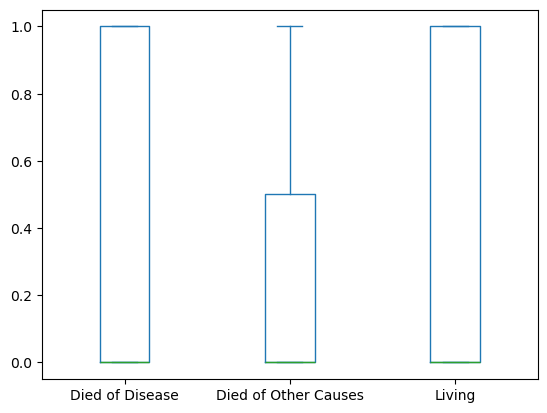

In [5]:
pd.crosstab(
    cancer_data["overall_survival_months"],
    cancer_data["death_from_cancer"],
    normalize="index"
).plot(kind="box", stacked=True)

plt.show()

# Correlations

In [6]:
['age_at_diagnosis', 'cancer_type_detailed', 'chemotherapy', 'tumor_stage', 'tumor_size', 'type_of_breast_surgery', 'death_from_cancer']
survival_age_correlation = cancer_data['overall_survival_months'].corr(cancer_data['age_at_diagnosis'], method='spearman')
survival_chemotherapy_correlation = cancer_data['overall_survival_months'].corr(cancer_data['chemotherapy'], method='spearman')
survival_tumor_stage_correlation = cancer_data['overall_survival_months'].corr(cancer_data['tumor_stage'], method='spearman')
survival_tumor_size_correlation = cancer_data['overall_survival_months'].corr(cancer_data['tumor_size'], method='spearman')

print(survival_age_correlation)
print(survival_chemotherapy_correlation)
print(survival_tumor_stage_correlation)
print(survival_tumor_size_correlation)


-0.14130924864941208
-0.16695575109956204
-0.2804146615795238
-0.22806547183981116


# Group work split
# Fenny: Section 3
# Jessica: section 2
# Chase: Section 6 and 7
# Harris: Section 4 and 5

## Section 3 Variables

In [7]:
# Define the target variable
y = cancer_data['overall_survival_months']


In [ ]:
# Predictors
X = cancer_data[
    ['age_at_diagnosis',
     'chemotherapy',
     'tumor_stage',
     'tumor_size']
]


In [ ]:
# Handle missing values by filling them with the median
X = X.fillna(X.median())
y = y.fillna(y.median())
X.isna().sum()


age_at_diagnosis    0
chemotherapy        0
tumor_stage         0
tumor_size          0
dtype: int64

In [ ]:
import statsmodels.api as sm

# Add constant
X_const = sm.add_constant(X)

# Fit linear regression
model = sm.OLS(y, X_const).fit()

print("AIC:", model.aic)
print("BIC:", model.bic)
print(model.summary())


NameError: name 'X' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Cross-Validation with Linear Regression
lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("CV MSE Scores:", -cv_scores)
print("Mean CV MSE:", -cv_scores.mean())


ModuleNotFoundError: No module named 'sklearn'

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Cross-Validation with Linear Regression
lr = LinearRegression()

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='neg_mean_squared_error'
)

print("CV MSE Scores:", -cv_scores)
print("Mean CV MSE:", -cv_scores.mean())


ModuleNotFoundError: No module named 'sklearn'